# RD validity checks
This notebook evaluates manipulation, balance, and pre-trend checks around
the close-election cutoff.

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

ROOT = Path.cwd().resolve()
if not (ROOT / "src").exists() and (ROOT.parent / "src").exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.paths import ANALYSIS_DIR, PAPER_FIGURES_DIR, PAPER_TABLES_DIR
from src.rd import density_discontinuity, rd_binned_means, rd_estimate, select_bandwidth
from src.viz_style import savefig, set_style

In [2]:
set_style()

sample_path = ANALYSIS_DIR / "close_elections_sample.parquet"
if not sample_path.exists():
    raise FileNotFoundError("Missing close-election sample. Run 11_construct_close_elections_rd_sample first.")

sample = pd.read_parquet(sample_path)

RUNNING = "running_var"
bandwidth = select_bandwidth(sample[RUNNING], quantile=0.3, max_bw=0.2)
if pd.isna(bandwidth):
    raise ValueError("Unable to select RD bandwidth.")

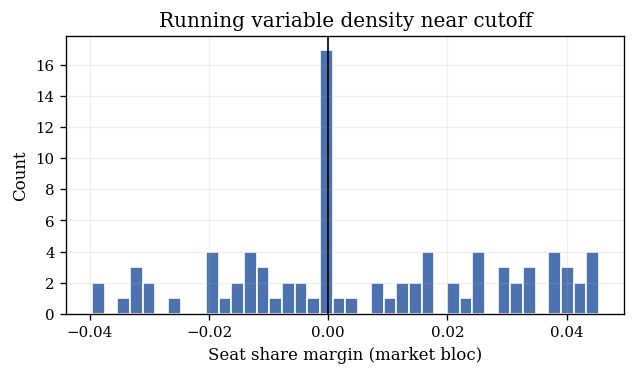

,left_n,right_n,log_diff,se,z_stat,bandwidth
0,29,58,0.693147,0.227429,3.047746,0.045455


In [3]:
fig, ax = plt.subplots(figsize=(6, 3))
subset = sample[sample[RUNNING].abs() <= bandwidth]
ax.hist(subset[RUNNING], bins=40, color="#4C72B0", edgecolor="white")
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Running variable density near cutoff")
ax.set_xlabel("Seat share margin (market bloc)")
ax.set_ylabel("Count")
display(fig)
savefig(fig, PAPER_FIGURES_DIR / "rd_density_hist")
plt.close(fig)

density_stats = density_discontinuity(sample[RUNNING], bandwidth=bandwidth)
density_df = pd.DataFrame([density_stats])
density_path = PAPER_TABLES_DIR / "rd_density_test.csv"
density_path.parent.mkdir(parents=True, exist_ok=True)
density_df.to_csv(density_path, index=False)
display(density_df.style.set_caption("Density discontinuity test (simple McCrary-style)"))

In [4]:
balance_vars = [
    "lag1_log_gdp_pc_const",
    "lag1_inv_share_gdp",
    "lag1_inflation_cpi_ann_pct",
    "lag1_trade_open_gdp",
    "lag1_efw_summary",
]

balance_rows = []
for var in balance_vars:
    if var not in sample.columns:
        continue
    estimate = rd_estimate(sample.dropna(subset=[var]), var, RUNNING, bandwidth=bandwidth, cluster="iso3c")
    balance_rows.append(
        {
            "variable": var,
            "coef": estimate.coef,
            "se": estimate.se,
            "pvalue": estimate.pvalue,
            "n_obs": estimate.n_obs,
            "bandwidth": estimate.bandwidth,
        }
    )

balance_df = pd.DataFrame(balance_rows)
balance_path = PAPER_TABLES_DIR / "rd_balance.csv"
balance_path.parent.mkdir(parents=True, exist_ok=True)
balance_df.to_csv(balance_path, index=False)
display(balance_df.style.set_caption("Covariate balance at the cutoff"))

,variable,coef,se,pvalue,n_obs,bandwidth
0,lag1_log_gdp_pc_const,-0.251685,0.292625,0.389736,84,0.045455
1,lag1_inv_share_gdp,-2.838904,2.705797,0.294089,84,0.045455
2,lag1_inflation_cpi_ann_pct,-0.160964,0.836890,0.847479,84,0.045455
3,lag1_trade_open_gdp,33.116796,12.755242,0.009423,84,0.045455
4,lag1_efw_summary,-0.334867,0.176355,0.057588,84,0.045455


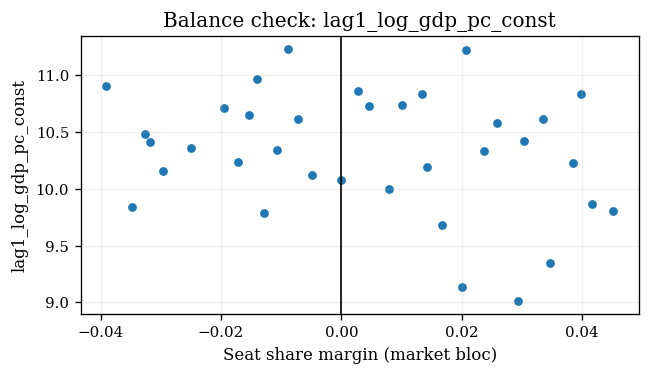

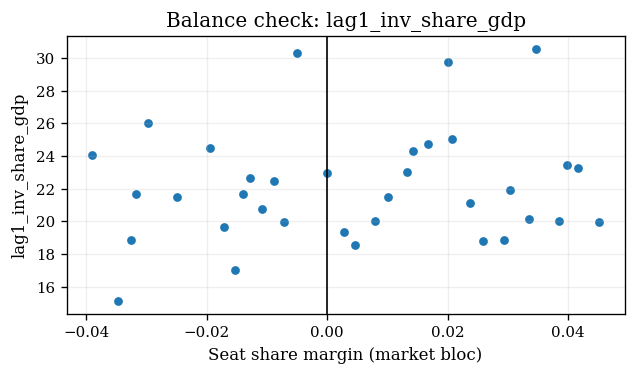

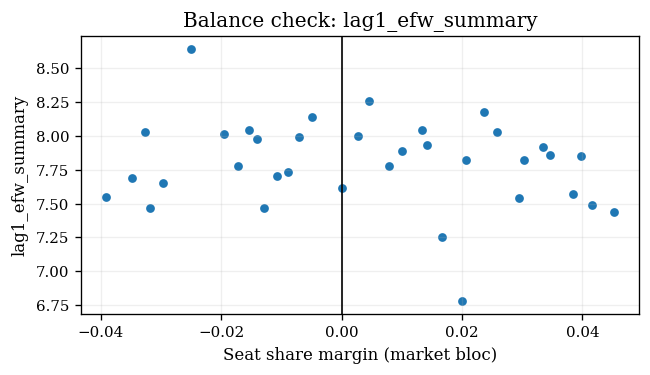

In [5]:
def plot_binned(outcome: str) -> None:
    if outcome not in sample.columns:
        return
    bins = rd_binned_means(sample.dropna(subset=[outcome]), outcome, RUNNING, bandwidth=bandwidth)
    fig, ax = plt.subplots(figsize=(6, 3))
    ax.scatter(bins["bin_center"], bins["mean_outcome"], s=18, color="#1F77B4")
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(f"Balance check: {outcome}")
    ax.set_xlabel("Seat share margin (market bloc)")
    ax.set_ylabel(outcome)
    display(fig)
    savefig(fig, PAPER_FIGURES_DIR / "balance" / f"rd_balance_{outcome}")
    plt.close(fig)


for outcome in ["lag1_log_gdp_pc_const", "lag1_inv_share_gdp", "lag1_efw_summary"]:
    plot_binned(outcome)

## Interpretation
The density plot and balance estimates provide the diagnostic groundwork for
a credible RD design: no sharp sorting around the cutoff and smooth pre-
election covariates support the local randomization assumption.